In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import matplotlib.patches as patches
import matplotlib as mpl
from mplsoccer import Pitch, VerticalPitch, FontManager, Sbopen, add_image
from matplotlib.font_manager import FontProperties
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects
from highlight_text import ax_text, fig_text
from PIL import Image
from mplsoccer import add_image
from urllib.request import urlopen
import os

import matplotlib.font_manager as fm

# Print the modified DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

green = '#69f900'
red = '#ff4b44'
blue = '#00a0de'
violet = '#a369ff'
bg_color= '#f5f5f5'
line_color= '#000000'
col1 = '#ff4b44'
col2 = '#00a0de'

# # UCL
# col1 = '#f659fd'
# col2 = '#33efff'
# bg_color = '#060F38'
# line_color = '#ffffff'
# green = '#69f900'
# red = '#ff4b44'

In [2]:
df = pd.read_csv(r"D:\FData\EPL_2024_25\epl_2024_25.csv")

In [38]:
df = pd.read_csv(r"D:\FData\EPL_2023-24\epl_2023_24.csv")

In [3]:
df = pd.read_csv(r"D:\FData\LaLiga_2024_25\laliga_2024_25.csv")

In [3]:
df = pd.read_csv(r"D:\FData\LaLiga_2023-24\laliga_2023_24.csv")

In [11]:
def defensive_shape(team_name):
    dft = df[(df['teamName']==team_name) | (df['oppositionTeamName']==team_name)]
    teamdf = dft[(dft['teamName']!=team_name) & (dft['type'].isin(['Pass', 'Carry'])) & 
                (~dft['qualifiers'].str.contains('GoalKick|Freekick|Corner|KickOff'))]
    # low = len(teamdf[teamdf['x']>70])
    # mid = len(teamdf[(teamdf['x']<=70) & (teamdf['x']>=35)])
    # hii = len(teamdf[teamdf['x']<35])
    low = len(teamdf[(teamdf['x']>65) & (teamdf['endX']-teamdf['x']<=5)])
    mid = len(teamdf[(teamdf['x']<=65) & (teamdf['x']>=35) & (teamdf['endX']-teamdf['x']<=5)])
    hii = len(teamdf[teamdf['x']<35])

    low_p = round((low/(low+mid+hii))*100)
    mid_p = round((mid/(low+mid+hii))*100)
    hii_p = round((hii/(low+mid+hii))*100)

    # Return the results as a dictionary
    return {
        'Low_Block': low_p,
        'Mid_Block': mid_p,
        'High_Block': hii_p
    }

# Get all unique team names from the DataFrame
all_teams = df['teamName'].unique()

# Create a list to store results for each team
team_results = []

# Apply defensive_shape function to each team with error handling
for team in all_teams:
    try:
        result = defensive_shape(team)
        if result:  # Only add if the function returns data
            team_results.append({
                'Team': team,
                'Low_Block_Percentage': result['Low_Block'],
                'Mid_Block_Percentage': result['Mid_Block'], 
                'High_Block_Percentage': result['High_Block']
            })
    except Exception as e:
        print(f"Error processing team {team}: {e}")

# Create DataFrame from results
teams_df = pd.DataFrame(team_results)

# Display the DataFrame
print("Defensive Shapes for All Teams:")
teams_df

Defensive Shapes for All Teams:


,Team,Low_Block_Percentage,Mid_Block_Percentage,High_Block_Percentage
0,Arsenal,27,29,44
1,Newcastle,30,32,37
2,Brentford,35,28,37
3,Bournemouth,27,29,43
4,Crystal Palace,27,35,38
5,Aston Villa,29,34,37
6,Brighton,21,32,47
7,Chelsea,21,31,49
8,Everton,27,34,40
9,Fulham,26,34,39


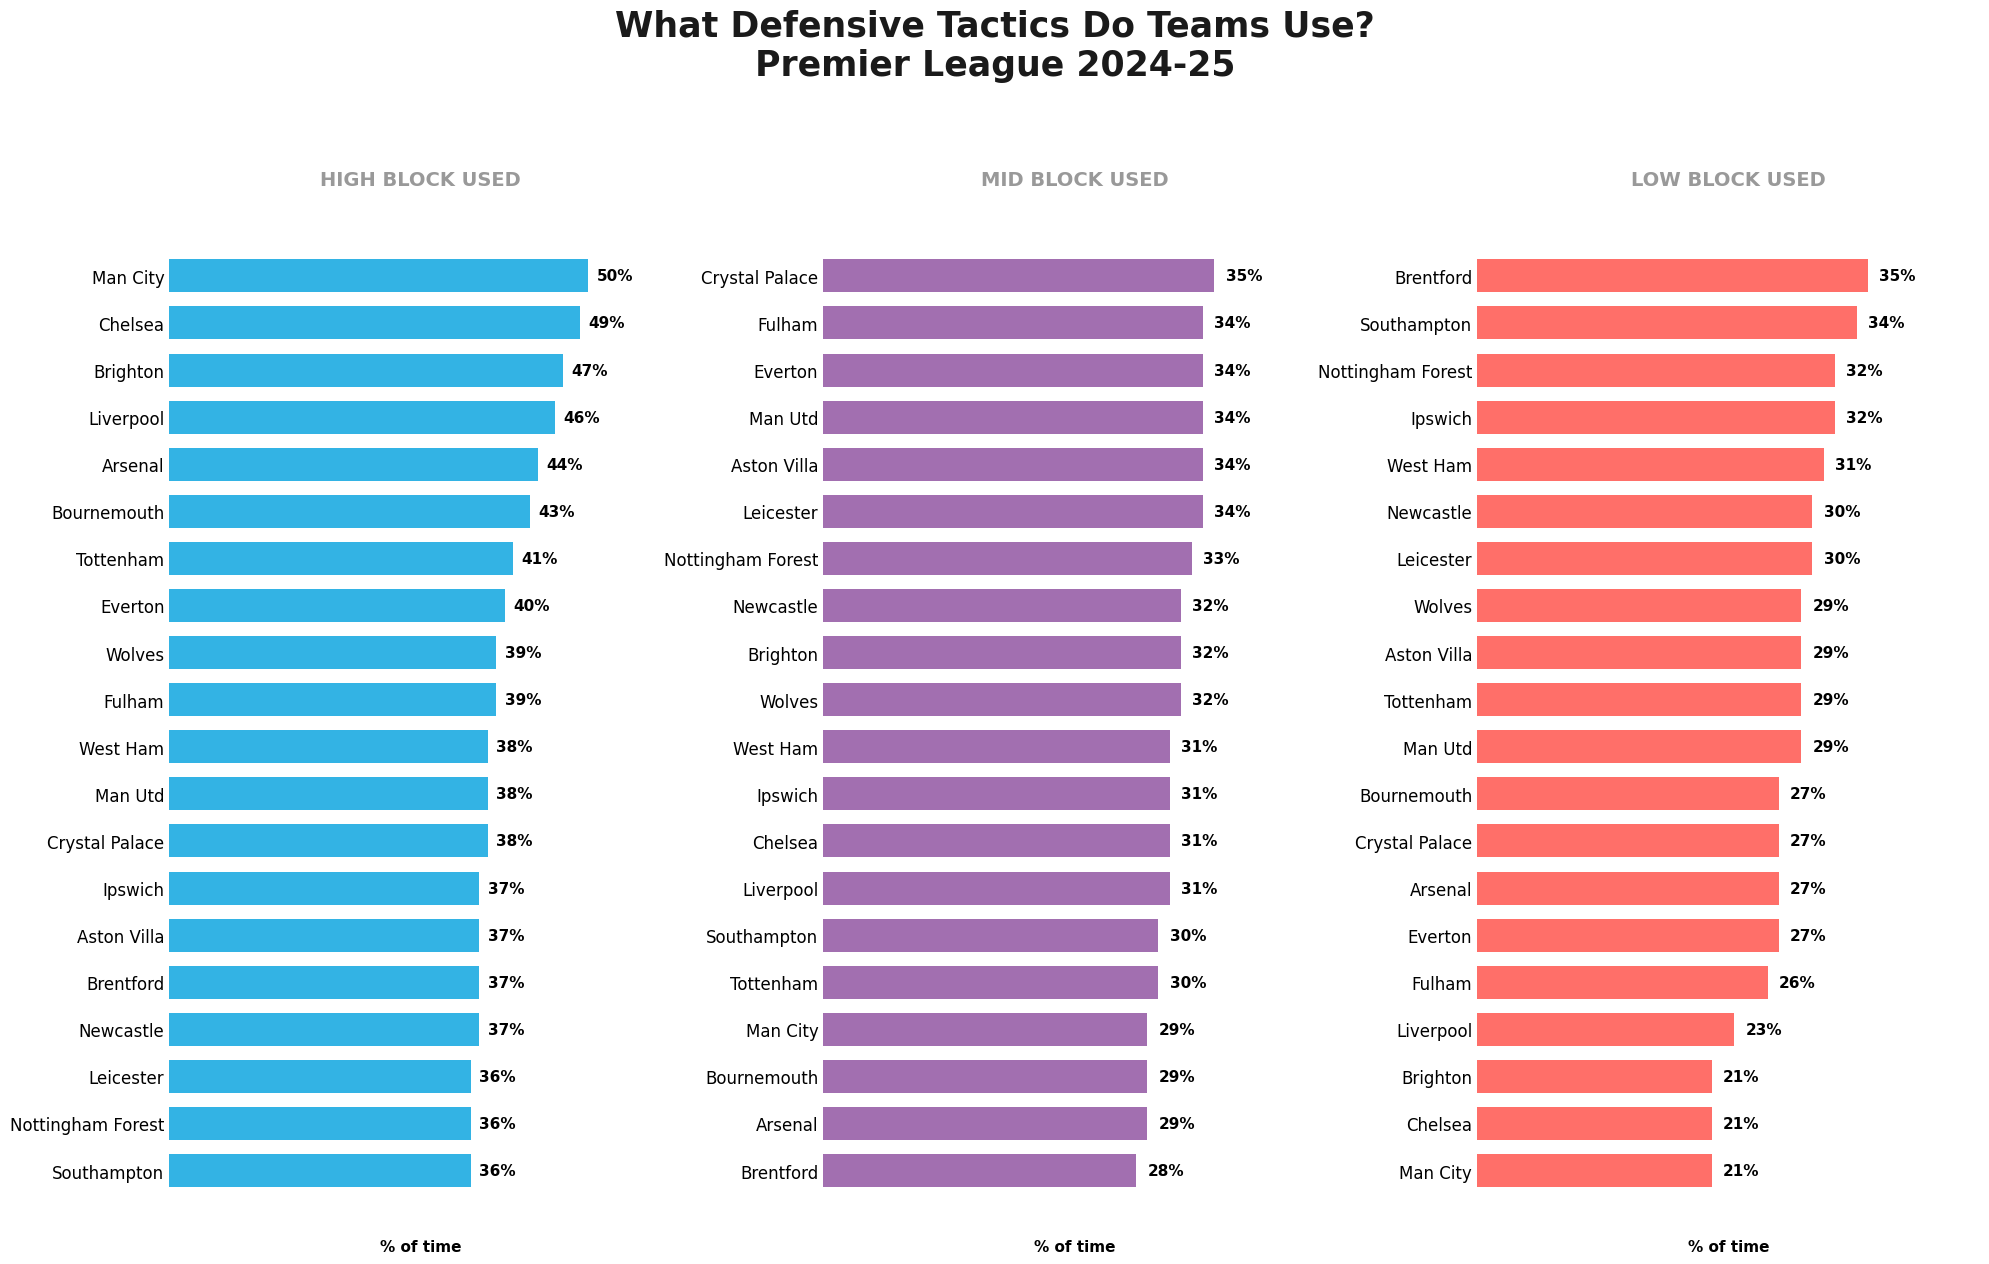

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def create_three_block_charts(teams_df):
    # Create figure with 3 subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 12))
    
    # Define colors for each block type
    colors = {
        'High_Block': col2,
        'Mid_Block': '#8B4B9C',
        'Low_Block': col1
    }
    
    # Chart 1: High Block (sorted by High Block percentage)
    df_high = teams_df.sort_values('High_Block_Percentage', ascending=True)
    teams_high = df_high['Team'].values
    high_values = df_high['High_Block_Percentage'].values
    y_pos_high = np.arange(len(teams_high))
    
    bars1 = ax1.barh(y_pos_high, high_values, height=0.7, 
                     color=colors['High_Block'], alpha=0.8)
    
    # Add percentage labels
    for i, (team, value) in enumerate(zip(teams_high, high_values)):
        ax1.text(value + 1, i, f'{value}%', va='center', fontweight='bold', fontsize=11)
    
    ax1.set_yticks(y_pos_high)
    ax1.set_yticklabels(teams_high, fontsize=12)
    ax1.set_xlabel('% of time', fontsize=11, fontweight='bold')
    ax1.set_title('HIGH BLOCK USED', fontsize=14, fontweight='bold', 
                  color='#999999', pad=20)
    ax1.set_xlim(0, max(high_values) + 10)
    ax1.set_xticks([])
    
    # Chart 2: Mid Block (sorted by Mid Block percentage)
    df_mid = teams_df.sort_values('Mid_Block_Percentage', ascending=True)
    teams_mid = df_mid['Team'].values
    mid_values = df_mid['Mid_Block_Percentage'].values
    y_pos_mid = np.arange(len(teams_mid))
    
    bars2 = ax2.barh(y_pos_mid, mid_values, height=0.7, 
                     color=colors['Mid_Block'], alpha=0.8)
    
    # Add percentage labels
    for i, (team, value) in enumerate(zip(teams_mid, mid_values)):
        ax2.text(value + 1, i, f'{value}%', va='center', fontweight='bold', fontsize=11)
    
    ax2.set_yticks(y_pos_mid)
    ax2.set_yticklabels(teams_mid, fontsize=12)
    ax2.set_xlabel('% of time', fontsize=11, fontweight='bold')
    ax2.set_title('MID BLOCK USED', fontsize=14, fontweight='bold', 
                  color='#999999', pad=20)
    ax2.set_xlim(0, max(mid_values) + 10)
    ax2.set_xticks([])
    
    # Chart 3: Low Block (sorted by Low Block percentage)
    df_low = teams_df.sort_values('Low_Block_Percentage', ascending=True)
    teams_low = df_low['Team'].values
    low_values = df_low['Low_Block_Percentage'].values
    y_pos_low = np.arange(len(teams_low))
    
    bars3 = ax3.barh(y_pos_low, low_values, height=0.7, 
                     color=colors['Low_Block'], alpha=0.8)
    
    # Add percentage labels
    for i, (team, value) in enumerate(zip(teams_low, low_values)):
        ax3.text(value + 1, i, f'{value}%', va='center', fontweight='bold', fontsize=11)
    
    ax3.set_yticks(y_pos_low)
    ax3.set_yticklabels(teams_low, fontsize=12)
    ax3.set_xlabel('% of time', fontsize=11, fontweight='bold')
    ax3.set_title('LOW BLOCK USED', fontsize=14, fontweight='bold', 
                  color='#999999', pad=20)
    ax3.set_xlim(0, max(low_values) + 10)
    ax3.set_xticks([])
    
    # Add main title
    fig.suptitle('What Defensive Tactics Do Teams Use?\nPremier League 2024-25', 
                 fontsize=25, fontweight='bold', y=1.05, color='#1a1a1a')
    
    # Style all axes
    for ax in [ax1, ax2, ax3]:
        # Remove spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        # ax.spines['bottom'].set_color('#cccccc')
        
        # Remove y-axis ticks
        ax.tick_params(axis='y', length=0)
        ax.tick_params(axis='x', length=0)
        # ax.tick_params(axis='x', colors='#666666')
        
        # # Add grid
        # ax.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
        # ax.set_axisbelow(True)
        
        # Set background
        ax.set_facecolor('white')
    
    # Set figure background
    fig.patch.set_facecolor('white')
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, wspace=0.3)
    
    return fig, (ax1, ax2, ax3)

# Usage example:
if 'teams_df' in locals() or 'teams_df' in globals():
    fig, axes = create_three_block_charts(teams_df)
    plt.show()
else:
    print("Please make sure you have created the 'teams_df' DataFrame first.")

Custom fonts loaded successfully!


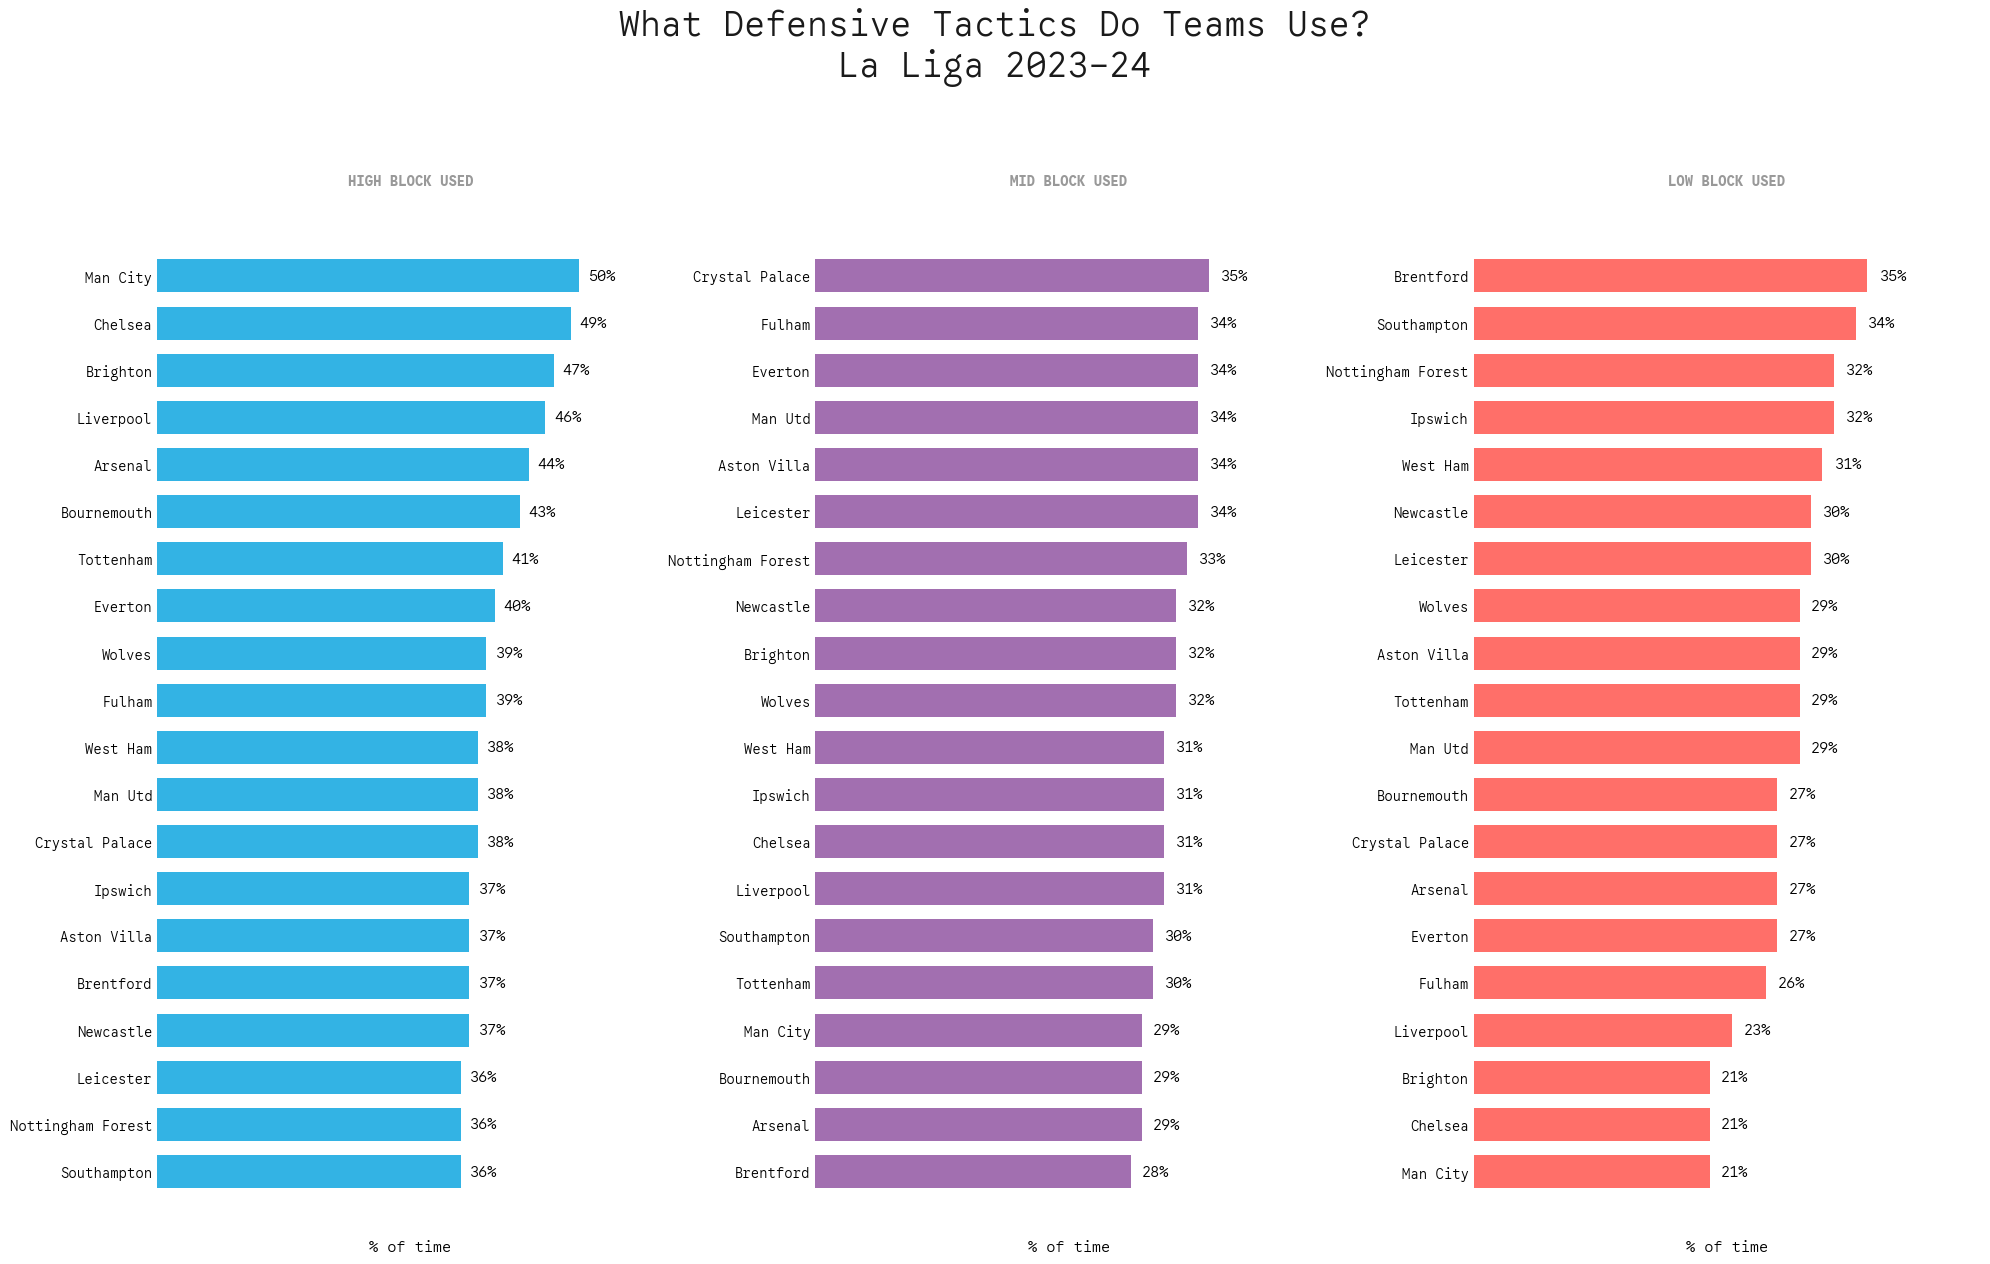

In [13]:
# Load custom fonts
# Update these paths to match your font file locations
bold_font_path = "C:\Fonts\Google_Sans_Code\static\GoogleSansCode-Bold.ttf"  # Update this path
light_font_path = "C:\Fonts\Google_Sans_Code\static\GoogleSansCode-Light.ttf"  # Update this path

# Register the fonts
try:
    bold_prop = fm.FontProperties(fname=bold_font_path)
    light_prop = fm.FontProperties(fname=light_font_path)
    fonts_loaded = True
    print("Custom fonts loaded successfully!")
except:
    print("Could not load custom fonts. Using default fonts.")
    bold_prop = fm.FontProperties(weight='bold')
    light_prop = fm.FontProperties(weight='light')
    fonts_loaded = False

def create_three_block_charts(teams_df):
    # Create figure with 3 subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 12))
    
    # Define colors for each block type
    colors = {
        'High_Block': col2,
        'Mid_Block': '#8B4B9C',
        'Low_Block': col1
    }
    
    # Chart 1: High Block (sorted by High Block percentage)
    df_high = teams_df.sort_values('High_Block_Percentage', ascending=True)
    teams_high = df_high['Team'].values
    high_values = df_high['High_Block_Percentage'].values
    y_pos_high = np.arange(len(teams_high))
    
    bars1 = ax1.barh(y_pos_high, high_values, height=0.7, 
                     color=colors['High_Block'], alpha=0.8)
    
    # Add percentage labels
    for i, (team, value) in enumerate(zip(teams_high, high_values)):
        ax1.text(value + 1, i, f'{value}%', va='center', fontsize=11, fontproperties=light_prop)
    
    ax1.set_yticks(y_pos_high)
    ax1.set_yticklabels(teams_high, fontsize=12, fontproperties=light_prop)
    ax1.set_xlabel('% of time', fontsize=11, fontproperties=light_prop)
    ax1.set_title('HIGH BLOCK USED', fontsize=14, 
                  color='#999999', pad=20, fontproperties=bold_prop)
    ax1.set_xlim(0, max(high_values) + 10)
    ax1.set_xticks([])
    
    # Chart 2: Mid Block (sorted by Mid Block percentage)
    df_mid = teams_df.sort_values('Mid_Block_Percentage', ascending=True)
    teams_mid = df_mid['Team'].values
    mid_values = df_mid['Mid_Block_Percentage'].values
    y_pos_mid = np.arange(len(teams_mid))
    
    bars2 = ax2.barh(y_pos_mid, mid_values, height=0.7, 
                     color=colors['Mid_Block'], alpha=0.8)
    
    # Add percentage labels
    for i, (team, value) in enumerate(zip(teams_mid, mid_values)):
        ax2.text(value + 1, i, f'{value}%', va='center', fontsize=11, fontproperties=light_prop)
    
    ax2.set_yticks(y_pos_mid)
    ax2.set_yticklabels(teams_mid, fontsize=12, fontproperties=light_prop)
    ax2.set_xlabel('% of time', fontsize=11, fontproperties=light_prop)
    ax2.set_title('MID BLOCK USED', fontsize=14, 
                  color='#999999', pad=20, fontproperties=bold_prop)
    ax2.set_xlim(0, max(mid_values) + 10)
    ax2.set_xticks([])
    
    # Chart 3: Low Block (sorted by Low Block percentage)
    df_low = teams_df.sort_values('Low_Block_Percentage', ascending=True)
    teams_low = df_low['Team'].values
    low_values = df_low['Low_Block_Percentage'].values
    y_pos_low = np.arange(len(teams_low))
    
    bars3 = ax3.barh(y_pos_low, low_values, height=0.7, 
                     color=colors['Low_Block'], alpha=0.8)
    
    # Add percentage labels
    for i, (team, value) in enumerate(zip(teams_low, low_values)):
        ax3.text(value + 1, i, f'{value}%', va='center', fontsize=11, fontproperties=light_prop)
    
    ax3.set_yticks(y_pos_low)
    ax3.set_yticklabels(teams_low, fontsize=12, fontproperties=light_prop)
    ax3.set_xlabel('% of time', fontsize=11, fontproperties=light_prop)
    ax3.set_title('LOW BLOCK USED', fontsize=14, 
                  color='#999999', pad=20, fontproperties=bold_prop)
    ax3.set_xlim(0, max(low_values) + 10)
    ax3.set_xticks([])
    
    # Add main title
    fig.suptitle('What Defensive Tactics Do Teams Use?\nLa Liga 2023-24',
                 fontsize=25, y=1.05, color='#1a1a1a', fontproperties=light_prop)
    
    # Style all axes
    for ax in [ax1, ax2, ax3]:
        # Remove spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        # ax.spines['bottom'].set_color('#cccccc')
        
        # Remove y-axis ticks
        ax.tick_params(axis='y', length=0)
        ax.tick_params(axis='x', length=0)
        # ax.tick_params(axis='x', colors='#666666')
        
        # # Add grid
        # ax.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
        # ax.set_axisbelow(True)
        
        # Set background
        ax.set_facecolor('white')
    
    # Set figure background
    fig.patch.set_facecolor('white')
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, wspace=0.3)
    
    return fig, (ax1, ax2, ax3)

# Usage example:
if 'teams_df' in locals() or 'teams_df' in globals():
    fig, axes = create_three_block_charts(teams_df)
    plt.show()
else:
    print("Please make sure you have created the 'teams_df' DataFrame first.")